# Modelado de la Curva de Crecimiento de Interacciones — v4

## Diagnóstico de v3 y cambios en esta versión

Los R² del panel completo en v3 eran bajos (~0.33 global, ~0.35-0.40 por plataforma, excepto Twitter con 0.69). El análisis de los outputs reveló tres causas:

1. **Facebook tenía `t0` pegado al límite** del bound (1.0 día), señal de que su curva tiene forma diferente, no solo offset diferente.
2. **Varianza intrínseca muy alta en el día 0**: el IQR va de 44.7% a 86.2% — 41pp de rango. Ningún modelo de forma universal puede capturar esto.
3. **El R² sobre el panel es la métrica equivocada** para el objetivo real. Lo que importa es: dado un total observado en un día específico, ¿qué tan bien estima el modelo el total final real?

## Cambios en v4

- **Diagnóstico de heterogeneidad**: antes de ajustar, cuantificamos cuánta varianza existe entre publicaciones vs. dentro de publicaciones.
- **Bound de `t0` ampliado a 2 días** para Facebook, que claramente necesita más offset.
- **Métrica de evaluación correcta**: error en estimación del total final, usando leave-one-out por publicación.
- **Modelo mixto opcional**: Weibull con `t0` por plataforma pero `k` y `α` globales, para evitar overfitting con pocas publicaciones.

## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import hashlib
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y preparación de datos

In [3]:
file_path = 'Scrapping data v2.xlsx'
xl = pd.ExcelFile(file_path)

df_fb = pd.read_excel(xl, sheet_name='Facebook')
df_ig = pd.read_excel(xl, sheet_name='Instagram')
df_tk = pd.read_excel(xl, sheet_name='TikTok')
df_tw = pd.read_excel(xl, sheet_name='Twitter')

def generate_id(text):
    if pd.isna(text): return 'missing_text'
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

if df_tw['postId'].isnull().all() or df_tw['postId'].astype(str).str.strip().eq('').all():
    df_tw['postId'] = df_tw['text'].apply(generate_id)

def prepare_evolution_df(df, platform, mapping, user_col, id_col, date_pub_col):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    actual_user_col = next(
        (col for col in [user_col, 'Username', 'name', 'Candidato'] if col in df.columns), None
    )
    df['candidate'] = df[actual_user_col].astype(str) if actual_user_col else 'Desconocido'
    df = df[~df['candidate'].str.contains('Desconocido|nan|None', case=False, na=True)]
    df['platform'] = platform
    df['internal_post_id'] = platform + '_' + df[id_col].astype(str)
    df = df.rename(columns=mapping)
    p_col = 'fecha_pub' if 'fecha_pub' in df.columns else (
        date_pub_col if date_pub_col in df.columns else None
    )
    df['fecha_ext'] = pd.to_datetime(df['fecha_ext'], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['fecha_pub'] = pd.to_datetime(df[p_col], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['dia_relativo'] = (df['fecha_ext'] - df['fecha_pub']).dt.days
    df = df[df['dia_relativo'] >= 0]
    for col in ['likes', 'comments', 'shares']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        else:
            df[col] = 0.0
    return df[['internal_post_id', 'platform', 'candidate', 'fecha_pub',
               'dia_relativo', 'likes', 'comments', 'shares']]

ev_fb = prepare_evolution_df(df_fb, 'Facebook',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidas': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_ig = prepare_evolution_df(df_ig, 'Instagram',
    {'megusta': 'likes', 'comentarios': 'comments'},
    'Username', 'postId', 'fecha_pub')
ev_tk = prepare_evolution_df(df_tk, 'TikTok',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidos': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_tw = prepare_evolution_df(df_tw, 'Twitter',
    {'likecount': 'likes', 'replycount': 'comments', 'retweet_count': 'shares'},
    'Username', 'postId', 'createdat')

df_combined = pd.concat([ev_fb, ev_ig, ev_tk, ev_tw], ignore_index=True)
df_combined['total_int'] = df_combined['likes'] + df_combined['comments'] + df_combined['shares']
print(f'Publicaciones únicas: {df_combined["internal_post_id"].nunique():,}')
print(f'Observaciones totales: {len(df_combined):,}')

Publicaciones únicas: 2,026
Observaciones totales: 19,439


## 2. Construcción del panel de fracciones

In [4]:
MIN_OBSERVACIONES = 2
MIN_DIA_MAX = 3

def build_fraction_panel(group):
    group = group.sort_values('dia_relativo').drop_duplicates('dia_relativo')
    if len(group) < MIN_OBSERVACIONES or group['dia_relativo'].max() < MIN_DIA_MAX:
        return None
    group = group.copy()
    group['total_int'] = group['total_int'].cummax()
    total_max = group.loc[group['dia_relativo'].idxmax(), 'total_int']
    if total_max <= 0:
        return None
    group['fraccion'] = (group['total_int'] / total_max).clip(0, 1)
    return group[['internal_post_id', 'platform', 'candidate',
                  'fecha_pub', 'dia_relativo', 'total_int', 'fraccion']]

panel_list = [build_fraction_panel(g) for _, g in df_combined.groupby('internal_post_id')]
df_panel = pd.concat([p for p in panel_list if p is not None], ignore_index=True)
print(f'Publicaciones en el panel: {df_panel["internal_post_id"].nunique():,}')
print(f'Pares (día, fracción): {len(df_panel):,}')

Publicaciones en el panel: 1,922
Pares (día, fracción): 14,596


## 3. Diagnóstico de heterogeneidad — ¿por qué el R² es bajo?

Descomponemos la varianza total de la fracción en dos componentes:
- **Varianza entre publicaciones** (distintas publicaciones tienen curvas de forma distinta)
- **Varianza dentro de publicaciones** (ruido de medición en la misma publicación)

Si la varianza *entre* publicaciones domina, el R² bajo es irreducible — el modelo captura bien la forma *promedio* pero las publicaciones individuales se desvían mucho entre sí. Si la varianza *dentro* domina, el problema es el modelo.

=== Descomposición de varianza ===
Varianza total:              0.0171
Varianza entre publicaciones: 0.0050  (29.2% del total)
Varianza dentro publicaciones:0.0114  (66.8% del total)

Interpretación:
- Si "entre" domina: las publicaciones tienen curvas muy distintas entre sí.
  El modelo promedio es correcto pero el R² será bajo inevitablemente.
- Si "dentro" domina: el modelo no está capturando bien la forma de la curva.



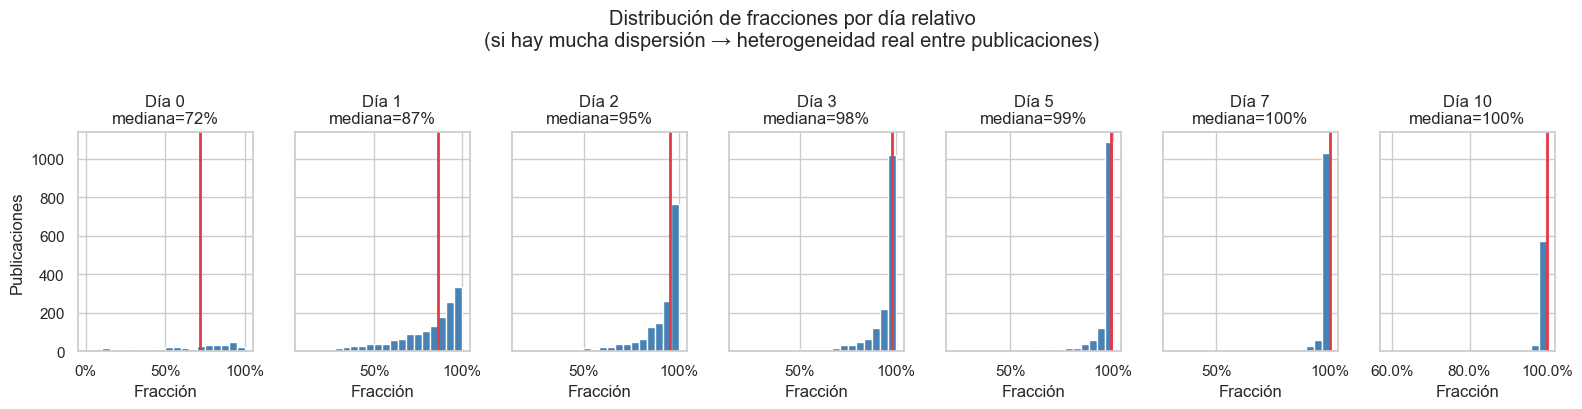

IQR de la fracción por día (cuánta dispersión hay entre publicaciones):
 dia_relativo      IQR
            0 0.414648
            1 0.248154
            2 0.115573
            3 0.071046
            5 0.033682
            7 0.009929
           10 0.000928

Un IQR alto en días tempranos indica que la velocidad de crecimiento
inicial varía mucho entre publicaciones — el offset t0 no es suficiente.


In [5]:
# Varianza total
var_total = df_panel['fraccion'].var()

# Varianza entre publicaciones: varianza de la fracción MEDIA de cada publicación
mean_frac_per_post = df_panel.groupby('internal_post_id')['fraccion'].mean()
var_entre = mean_frac_per_post.var()

# Varianza dentro: varianza de los residuos respecto a la media de cada publicación
df_panel['frac_media_post'] = df_panel.groupby('internal_post_id')['fraccion'].transform('mean')
var_dentro = (df_panel['fraccion'] - df_panel['frac_media_post']).var()

print('=== Descomposición de varianza ===')
print(f'Varianza total:              {var_total:.4f}')
print(f'Varianza entre publicaciones: {var_entre:.4f}  ({var_entre/var_total:.1%} del total)')
print(f'Varianza dentro publicaciones:{var_dentro:.4f}  ({var_dentro/var_total:.1%} del total)')
print()
print('Interpretación:')
print('- Si "entre" domina: las publicaciones tienen curvas muy distintas entre sí.')
print('  El modelo promedio es correcto pero el R² será bajo inevitablemente.')
print('- Si "dentro" domina: el modelo no está capturando bien la forma de la curva.')
print()

# Visualización: distribución de la fracción en cada día, por plataforma
dias_clave = [0, 1, 2, 3, 5, 7, 10]
dias_disponibles = [d for d in dias_clave if d in df_panel['dia_relativo'].values]

fig, axes = plt.subplots(1, len(dias_disponibles), figsize=(16, 4), sharey=True)
for ax, dia in zip(axes, dias_disponibles):
    sub = df_panel[df_panel['dia_relativo'] == dia]
    ax.hist(sub['fraccion'], bins=20, color='steelblue', edgecolor='white')
    med = sub['fraccion'].median()
    ax.axvline(med, color='#E63946', linewidth=2)
    ax.set_title(f'Día {dia}\nmediana={med:.0%}')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Fracción')
    if ax == axes[0]:
        ax.set_ylabel('Publicaciones')

plt.suptitle('Distribución de fracciones por día relativo\n'
             '(si hay mucha dispersión → heterogeneidad real entre publicaciones)', y=1.02)
plt.tight_layout()
plt.show()

# IQR por día: cuantifica cuánta dispersión hay
iqr_por_dia = df_panel.groupby('dia_relativo')['fraccion'].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index()
iqr_por_dia.columns = ['dia_relativo', 'IQR']
print('IQR de la fracción por día (cuánta dispersión hay entre publicaciones):')
print(iqr_por_dia[iqr_por_dia['dia_relativo'].isin(dias_disponibles)].to_string(index=False))
print()
print('Un IQR alto en días tempranos indica que la velocidad de crecimiento')
print('inicial varía mucho entre publicaciones — el offset t0 no es suficiente.')

## 4. Ajuste de modelos por plataforma

Dado que el R² global es bajo por heterogeneidad entre publicaciones, **el R² del panel no es la métrica que importa**. Lo que importa es la métrica de uso real:

> Dado el total de interacciones observado en el día `t`, ¿qué tan bien estima el modelo el total final?

Esa evaluación viene en la celda 5. Primero ajustamos modelos por plataforma con bound ampliado para Facebook.

Facebook     | k=0.9480, α=0.8230, t0=1.9323 (46.4h) | R²=0.3514
Instagram    | k=1.1369, α=0.5210, t0=0.0408 (1.0h) | R²=0.4026
TikTok       | k=1.3272, α=0.5124, t0=0.7887 (18.9h) | R²=0.3509
Twitter      | k=1.4453, α=1.1422, t0=0.2566 (6.2h) | R²=0.6905


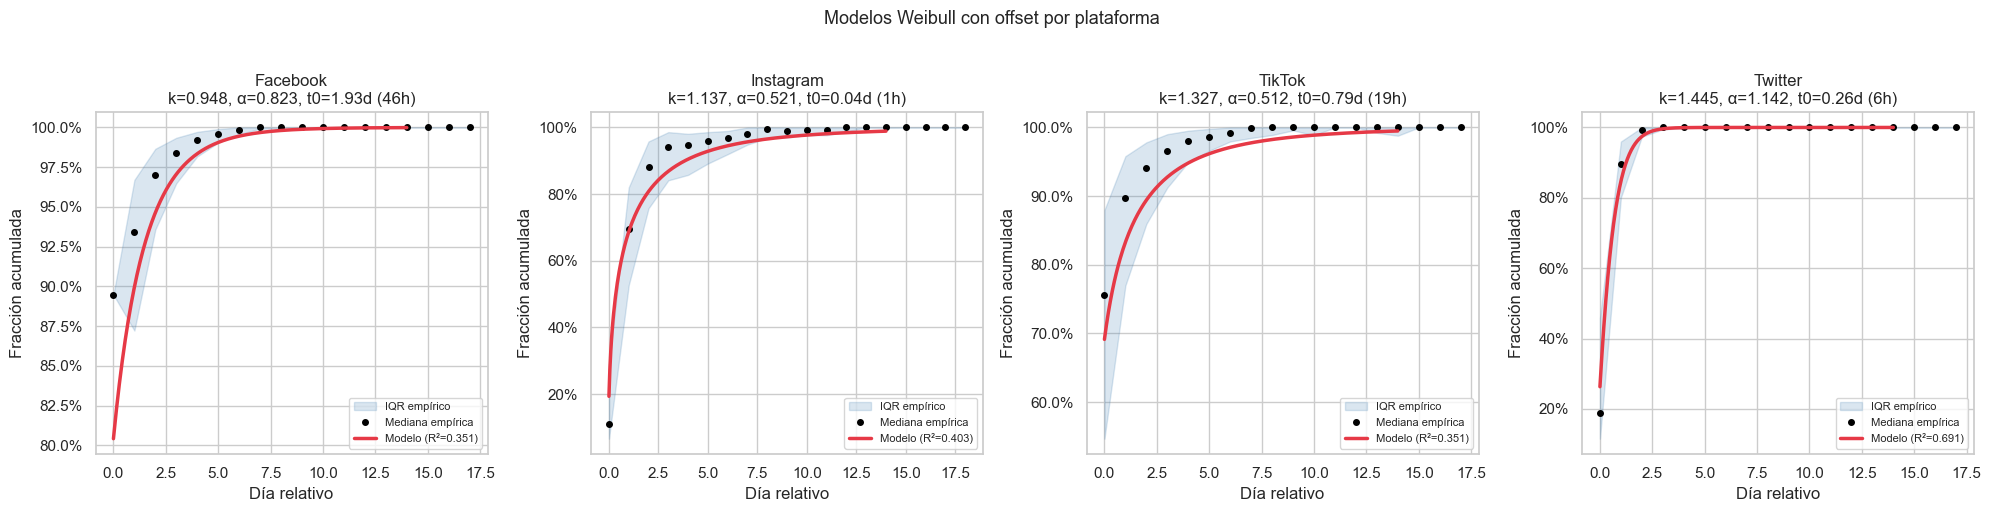

In [6]:
def weibull_offset(t, k, alpha, t0):
    """F(t) = 1 - exp(-k * (t + t0)^alpha)"""
    return 1 - np.exp(-k * np.power(np.maximum(t + t0, 1e-9), alpha))

# Bounds por plataforma: Facebook necesita t0 más alto
PLATFORM_BOUNDS = {
    'Facebook':  ([0, 0, 0], [np.inf, np.inf, 2.0]),   # hasta 2 días de offset
    'Instagram': ([0, 0, 0], [np.inf, np.inf, 1.0]),
    'TikTok':    ([0, 0, 0], [np.inf, np.inf, 1.0]),
    'Twitter':   ([0, 0, 0], [np.inf, np.inf, 1.0]),
}

P0_LIST = [[0.5, 0.5, 0.5], [0.1, 0.8, 0.3], [1.0, 0.4, 0.8], [1.5, 0.6, 1.0]]

platform_models = {}
plats = df_panel['platform'].unique()

fig, axes = plt.subplots(1, len(plats), figsize=(5 * len(plats), 5))
t_plot = np.linspace(0, 14, 300)

for i, platform in enumerate(plats):
    sub = df_panel[df_panel['platform'] == platform]
    x_p = sub['dia_relativo'].values.astype(float)
    y_p = sub['fraccion'].values.astype(float)
    bounds = PLATFORM_BOUNDS.get(platform, ([0, 0, 0], [np.inf, np.inf, 1.0]))

    best_r2, best_popt = -np.inf, None
    for p0 in P0_LIST:
        try:
            popt, _ = curve_fit(weibull_offset, x_p, y_p, p0=p0,
                                maxfev=50000, bounds=bounds)
            r2 = r2_score(y_p, weibull_offset(x_p, *popt))
            if r2 > best_r2:
                best_r2, best_popt = r2, popt
        except Exception:
            continue

    ax = axes[i] if len(plats) > 1 else axes

    if best_popt is not None:
        k, alpha, t0 = best_popt
        platform_models[platform] = {'params': best_popt, 'r2': best_r2, 'func': weibull_offset}

        med_p = sub.groupby('dia_relativo')['fraccion'].median()
        q25_p = sub.groupby('dia_relativo')['fraccion'].quantile(0.25)
        q75_p = sub.groupby('dia_relativo')['fraccion'].quantile(0.75)

        ax.fill_between(q25_p.index, q25_p.values, q75_p.values,
                        alpha=0.2, color='steelblue', label='IQR empírico')
        ax.plot(med_p.index, med_p.values, 'o', color='black',
                markersize=4, label='Mediana empírica')
        y_curve = np.clip(weibull_offset(t_plot, *best_popt), 0, 1)
        ax.plot(t_plot, y_curve, color='#E63946', linewidth=2.5,
                label=f'Modelo (R²={best_r2:.3f})')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_title(f'{platform}\nk={k:.3f}, α={alpha:.3f}, t0={t0:.2f}d ({t0*24:.0f}h)')
        ax.set_xlabel('Día relativo')
        ax.set_ylabel('Fracción acumulada')
        ax.legend(fontsize=8)

        at_bound = t0 >= bounds[1][2] * 0.99
        print(f'{platform:12s} | k={k:.4f}, α={alpha:.4f}, t0={t0:.4f} ({t0*24:.1f}h) | '
              f'R²={best_r2:.4f}' + (' ⚠ t0 en límite' if at_bound else ''))
    else:
        print(f'{platform:12s} | No convergió')

plt.suptitle('Modelos Weibull con offset por plataforma', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Evaluación con la métrica correcta: error en estimación del total final

Para cada publicación con suficientes observaciones, simulamos el escenario real:
- Tomamos una observación temprana (día `t_obs`)
- Usamos el modelo para estimar el total final: `N_est = observado / F(t_obs)`
- Comparamos con el total real observado al final del período

El error porcentual absoluto medio (MAPE) en esta estimación es la métrica que realmente importa.

In [7]:
# Para cada publicación: tomamos el valor de cada día observado como
# "observación parcial" y estimamos el total final. Luego comparamos
# con el total real (último día observado de esa publicación).

errores = []

for post_id, group in df_panel.groupby('internal_post_id'):
    group = group.sort_values('dia_relativo')
    platform = group['platform'].iloc[0]

    if platform not in platform_models:
        continue

    params = platform_models[platform]['params']
    func = platform_models[platform]['func']

    # Total real = último valor observado
    total_real = group.loc[group['dia_relativo'].idxmax(), 'total_int']
    if total_real <= 0:
        continue

    # Para cada observación intermedia, estimar el total final
    for _, row in group.iterrows():
        t_obs = row['dia_relativo']
        n_obs = row['total_int']

        if n_obs <= 0:
            continue

        f_t = np.clip(func(float(t_obs), *params), 0.01, 1.0)
        total_estimado = n_obs / f_t
        error_pct = abs(total_estimado - total_real) / total_real * 100

        errores.append({
            'internal_post_id': post_id,
            'platform': platform,
            'dia_observacion': t_obs,
            'total_real': total_real,
            'total_estimado': total_estimado,
            'error_pct': error_pct
        })

df_errores = pd.DataFrame(errores)

print('=== Error en estimación del total final (MAPE por día de observación) ===')
print()
pivot = df_errores.groupby(['platform', 'dia_observacion'])['error_pct'].median().unstack('dia_observacion')
dias_mostrar = [d for d in [0, 1, 2, 3, 5, 7, 10] if d in pivot.columns]
print(pivot[dias_mostrar].round(1).to_string())
print()
print('Valores = error porcentual absoluto mediano al estimar el total final')
print('desde una observación en ese día relativo.')
print('Un valor de 20 significa que el modelo se equivoca en ±20% del total.')

=== Error en estimación del total final (MAPE por día de observación) ===

dia_observacion    0     1     2     3    5    7    10
platform                                              
Facebook         11.3   6.9   3.7   2.1  0.7  0.3  0.1
Instagram        64.8  20.7  15.7  12.1  5.9  3.8  2.3
TikTok           25.4  14.2   8.3   5.9  3.2  2.3  1.1
Twitter          56.4  11.1   2.5   0.4  0.0  0.0  0.0

Valores = error porcentual absoluto mediano al estimar el total final
desde una observación en ese día relativo.
Un valor de 20 significa que el modelo se equivoca en ±20% del total.


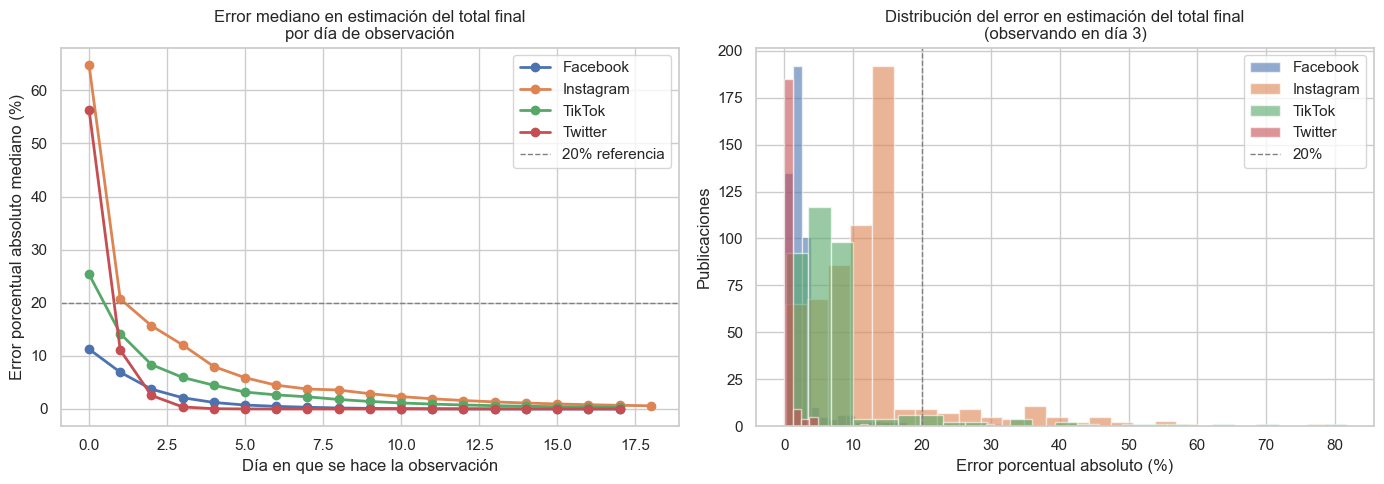

Publicaciones con error < 20% al día 3:
platform
Facebook     99.0% (472/477)
Instagram    89.7% (530/591)
TikTok       93.3% (321/344)
Twitter      99.5% (204/205)
dtype: object


In [8]:
# Gráfico del error por día de observación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: MAPE mediano por día y plataforma
for platform, grp in df_errores.groupby('platform'):
    mape_by_day = grp.groupby('dia_observacion')['error_pct'].median()
    axes[0].plot(mape_by_day.index, mape_by_day.values,
                 marker='o', linewidth=2, label=platform)

axes[0].set_title('Error mediano en estimación del total final\npor día de observación')
axes[0].set_xlabel('Día en que se hace la observación')
axes[0].set_ylabel('Error porcentual absoluto mediano (%)')
axes[0].axhline(20, color='gray', linestyle='--', linewidth=1, label='20% referencia')
axes[0].legend()

# Panel derecho: distribución del error al día 3 (umbral razonable)
dia_ref = 3
sub_ref = df_errores[df_errores['dia_observacion'] == dia_ref]
for platform, grp in sub_ref.groupby('platform'):
    axes[1].hist(grp['error_pct'].clip(0, 100), bins=25, alpha=0.6, label=platform)

axes[1].set_title(f'Distribución del error en estimación del total final\n'
                  f'(observando en día {dia_ref})')
axes[1].set_xlabel('Error porcentual absoluto (%)')
axes[1].set_ylabel('Publicaciones')
axes[1].axvline(20, color='gray', linestyle='--', linewidth=1, label='20%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Publicaciones con error < 20% al día {dia_ref}:')
print(sub_ref.groupby('platform').apply(
    lambda g: f"{(g['error_pct'] < 20).mean():.1%} ({(g['error_pct'] < 20).sum()}/{len(g)})"
))

## 6. Función de reconstrucción histórica

In [9]:
def reconstruir_curva(
    fecha_pub,
    total_interacciones,
    fecha_observacion=None,
    platform=None,
    dias_reconstruir=20,
    platform_models=platform_models
):
    """
    Reconstruye la curva histórica de interacciones de una publicación.

    Parámetros
    ----------
    fecha_pub : str o datetime — fecha de publicación.
    total_interacciones : int — interacciones observadas.
        Si se da fecha_observacion, es una medición parcial y se escala.
        Si no, se trata como total final.
    fecha_observacion : str o datetime, opcional — cuándo se midió.
    platform : str — 'Facebook', 'Instagram', 'TikTok', 'Twitter'.
    dias_reconstruir : int — días hacia adelante a mostrar.

    Retorna
    -------
    pd.DataFrame con la curva reconstruida.
    """
    fecha_pub = pd.to_datetime(fecha_pub)

    if platform and platform in platform_models:
        func = platform_models[platform]['func']
        params = platform_models[platform]['params']
    else:
        # Fallback: primer modelo disponible
        first = next(iter(platform_models.values()))
        func, params = first['func'], first['params']
        print(f'⚠ Plataforma no reconocida. Usando modelo global de referencia.')

    if fecha_observacion is not None:
        fecha_obs = pd.to_datetime(fecha_observacion)
        dia_obs = max(0, (fecha_obs - fecha_pub).days)
        f_obs = np.clip(func(float(dia_obs), *params), 0.01, 1.0)
        total_final = total_interacciones / f_obs
        print(f'Día de observación: {dia_obs} | '
              f'F(t) estimado: {f_obs:.1%} | '
              f'Total final estimado: {total_final:,.0f}')
    else:
        total_final = total_interacciones
        print(f'Total final (dado): {total_final:,.0f}')

    dias = np.arange(0, dias_reconstruir + 1)
    fraccion = np.clip(func(dias.astype(float), *params), 0, 1)
    # Normalizar para que el horizonte final = 100%
    f_max = func(float(dias_reconstruir), *params)
    if f_max > 0:
        fraccion = np.clip(fraccion / f_max, 0, 1)

    cum = np.round(fraccion * total_final).astype(int)
    nuevas = np.diff(cum, prepend=0)
    fechas = [fecha_pub + pd.Timedelta(days=int(d)) for d in dias]

    return pd.DataFrame({
        'Fecha': fechas,
        'Día Relativo': dias,
        '% Acumulado': fraccion,
        'Interacciones Estimadas': cum,
        'Interacciones Nuevas (ese día)': nuevas
    })

Total final (dado): 50,000
     Fecha  Día Relativo  % Acumulado  Interacciones Estimadas  Interacciones Nuevas (ese día)
2026-01-15             0     0.804123                    40206                           40206
2026-01-16             1     0.899533                    44977                            4771
2026-01-17             2     0.946370                    47319                            2342
2026-01-18             3     0.970562                    48528                            1209
2026-01-19             4     0.983494                    49175                             647
2026-01-20             5     0.990587                    49529                             354
2026-01-21             6     0.994556                    49728                             199
2026-01-22             7     0.996814                    49841                             113
2026-01-23             8     0.998117                    49906                              65
2026-01-24             

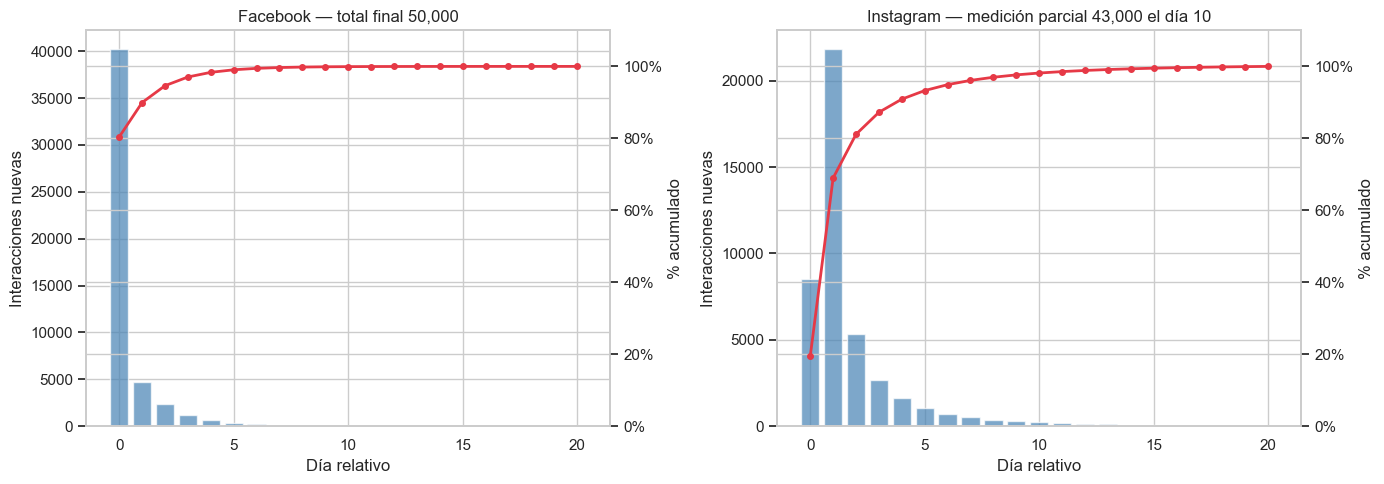

In [10]:
# Ejemplo A: total final conocido
curva_a = reconstruir_curva('2026-01-15', 50_000, platform='Facebook')
print(curva_a.to_string(index=False))
print()

# Ejemplo B: medición parcial
curva_b = reconstruir_curva(
    '2026-01-15', 43_000,
    fecha_observacion='2026-01-25',
    platform='Instagram'
)
print(curva_b.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (curva, titulo) in zip(axes, [
    (curva_a, 'Facebook — total final 50,000'),
    (curva_b, 'Instagram — medición parcial 43,000 el día 10')
]):
    ax.bar(curva['Día Relativo'], curva['Interacciones Nuevas (ese día)'],
           color='steelblue', alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(curva['Día Relativo'], curva['% Acumulado'],
             color='#E63946', linewidth=2, marker='o', markersize=4)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax2.set_ylim(0, 1.1)
    ax.set_title(titulo)
    ax.set_xlabel('Día relativo')
    ax.set_ylabel('Interacciones nuevas')
    ax2.set_ylabel('% acumulado')
plt.tight_layout()
plt.show()